In [2]:
import os
import numpy as np
import cv2

from distutils.archive_util import make_archive
from imutils.object_detection import non_max_suppression
from multiprocessing import Pool
from tqdm.auto import tqdm

In [21]:
"""
src: https://pyimagesearch.com/2018/08/20/opencv-text-detection-east-text-detector/
"""
#source_dir = '../data/hateful_memes/img'
#source_dir = '../data/hateful_memes/img'
#target_dir_masked = '../data/hateful_memes_masked'
target_dir_inpainted = '../data/hateful_memes_inpainted'
source_dir = 'C:/Users/gidle/Desktop/Year3/NLP/Project/Hateful memes challenge/DATA/img'
target_dir_masked = 'C:/Users/gidle/Desktop/Year3/NLP/Project/Hateful memes challenge/DATA/masked'
target_dir_inpainted = 'C:/Users/gidle/Desktop/Year3/NLP/Project/Hateful memes challenge/DATA/inpainted'
east_path = 'C:/Users/gidle/Desktop/Year3/NLP/Project/Hateful memes challenge/MODEL/frozen_east_text_detection.pb'
width = 640
height = 640
min_confidence = 0.5
img_fns = [x for x in os.listdir(source_dir) if x.endswith('.png')]

In [ ]:
def transform_image(img_fp):
    # Load the input image and grab the image dimensions
    image = cv2.imread(img_fp)
    masked, inpainted = image.copy(), image.copy()
    (H, W) = image.shape[:2]
    
    # Set the new width and height and determine the ratio in change
    (newW, newH) = (width, height)
    rW = W / float(newW)
    rH = H / float(newH)
    
    # Resize the image and grab the new image dimensions
    image = cv2.resize(image, (newW, newH))
    (H, W) = image.shape[:2]

    # Construct a blob and perform forward pass
    blob = cv2.dnn.blobFromImage(image, 1.0, (W, H),
        (123.68, 116.78, 103.94), swapRB=True, crop=False)
    net.setInput(blob)
    (scores, geometry) = net.forward(layerNames)

    # Process the network outputs
    (numRows, numCols) = scores.shape[2:4]
    rects = []
    confidences = []
    
    for y in range(0, numRows):
        scoresData = scores[0, 0, y]
        xData0 = geometry[0, 0, y]
        xData1 = geometry[0, 1, y]
        xData2 = geometry[0, 2, y]
        xData3 = geometry[0, 3, y]
        anglesData = geometry[0, 4, y]

        for x in range(0, numCols):
            if scoresData[x] < min_confidence:
                continue
            (offsetX, offsetY) = (x * 4.0, y * 4.0)
            angle = anglesData[x]
            cos = np.cos(angle)
            sin = np.sin(angle)
            h = xData0[x] + xData2[x]
            w = xData1[x] + xData3[x]
            endX = int(offsetX + (cos * xData1[x]) + (sin * xData2[x]))
            endY = int(offsetY - (sin * xData1[x]) + (cos * xData2[x]))
            startX = int(endX - w)
            startY = int(endY - h)
            rects.append((startX, startY, endX, endY))
            confidences.append(scoresData[x])

    # Merge text boxes in the same line (original implementation)
    if len(rects) > 0:
        rects = np.array(rects)
        
        centers_y = (rects[:, 1] + rects[:, 3]) / 2
        heights = rects[:, 3] - rects[:, 1]
        avg_height = np.mean(heights)
        
        rows = []
        current_row = [rects[0]]
        for i in range(1, len(rects)):
            if abs(centers_y[i] - centers_y[i-1]) < avg_height / 2:
                current_row.append(rects[i])
            else:
                rows.append(current_row)
                current_row = [rects[i]]
        rows.append(current_row)
        
        merged_boxes = []
        for row in rows:
            row = np.array(row)
            min_x = np.min(row[:, 0])
            min_y = np.min(row[:, 1])
            max_x = np.max(row[:, 2])
            max_y = np.max(row[:, 3])
            merged_boxes.append([min_x, min_y, max_x, max_y])
        
        boxes = merged_boxes
    else:
        boxes = []

    # Generate mask (original implementation)
    mask_for_inpainting = np.zeros(inpainted.shape[:2], np.uint8)
    for (startX, startY, endX, endY) in boxes:
        startX = int(startX * rW)
        startY = int(startY * rH)
        endX = int(endX * rW)
        endY = int(endY * rH)
        cv2.rectangle(masked, (startX, startY), (endX, endY), (127, 127, 127), -1)
        cv2.rectangle(mask_for_inpainting, (startX, startY), (endX, endY), 255, -1)

    
    # Step 1: Prepare the mask
    # Apply morphological operations to clean up the mask
    kernel = np.ones((3, 3), np.uint8)
    refined_mask = cv2.morphologyEx(mask_for_inpainting, cv2.MORPH_CLOSE, kernel)
    refined_mask = cv2.morphologyEx(refined_mask, cv2.MORPH_OPEN, kernel)
    
    # Step 2: Multi-scale inpainting approach
    # First pass - inpaint with larger radius for main content
    inpaint_radius = 7
    inpainted_large = cv2.inpaint(inpainted, refined_mask, inpaint_radius, cv2.INPAINT_NS)
    
    # Second pass - inpaint with smaller radius for details
    # Create a border mask to focus on edges
    edges = cv2.Canny(refined_mask, 100, 200)
    border_mask = cv2.dilate(edges, kernel, iterations=1)
    inpaint_radius = 3
    inpainted_small = cv2.inpaint(inpainted_large, border_mask, inpaint_radius, cv2.INPAINT_TELEA)
    
    # Step 3: Edge-aware blending
    # Create weight map based on distance from mask edges
    dist_transform = cv2.distanceTransform(255 - refined_mask, cv2.DIST_L2, 5)
    dist_transform = cv2.normalize(dist_transform, None, 0, 1.0, cv2.NORM_MINMAX)
    
    # Combine results with edge-aware weights
    inpainted = cv2.addWeighted(
        inpainted_large, 0.6, 
        inpainted_small, 0.4, 
        0
    )
    
    # Step 4: Post-processing
    # Apply slight blur to inpainted regions for better blending
    inpainted_region = cv2.bitwise_and(inpainted, inpainted, mask=refined_mask)
    inpainted_region = cv2.GaussianBlur(inpainted_region, (3, 3), 0)
    
    # Combine with original image outside mask
    background = cv2.bitwise_and(inpainted, inpainted, mask=255-refined_mask)
    inpainted = cv2.add(inpainted_region, background)

    return masked, inpainted

In [42]:
layerNames = [
	"feature_fusion/Conv_7/Sigmoid",
	"feature_fusion/concat_3"
    ]
print("[INFO] loading EAST text detector...")
net = cv2.dnn.readNet(east_path)

[INFO] loading EAST text detector...



Visualizing results for: 34952.png


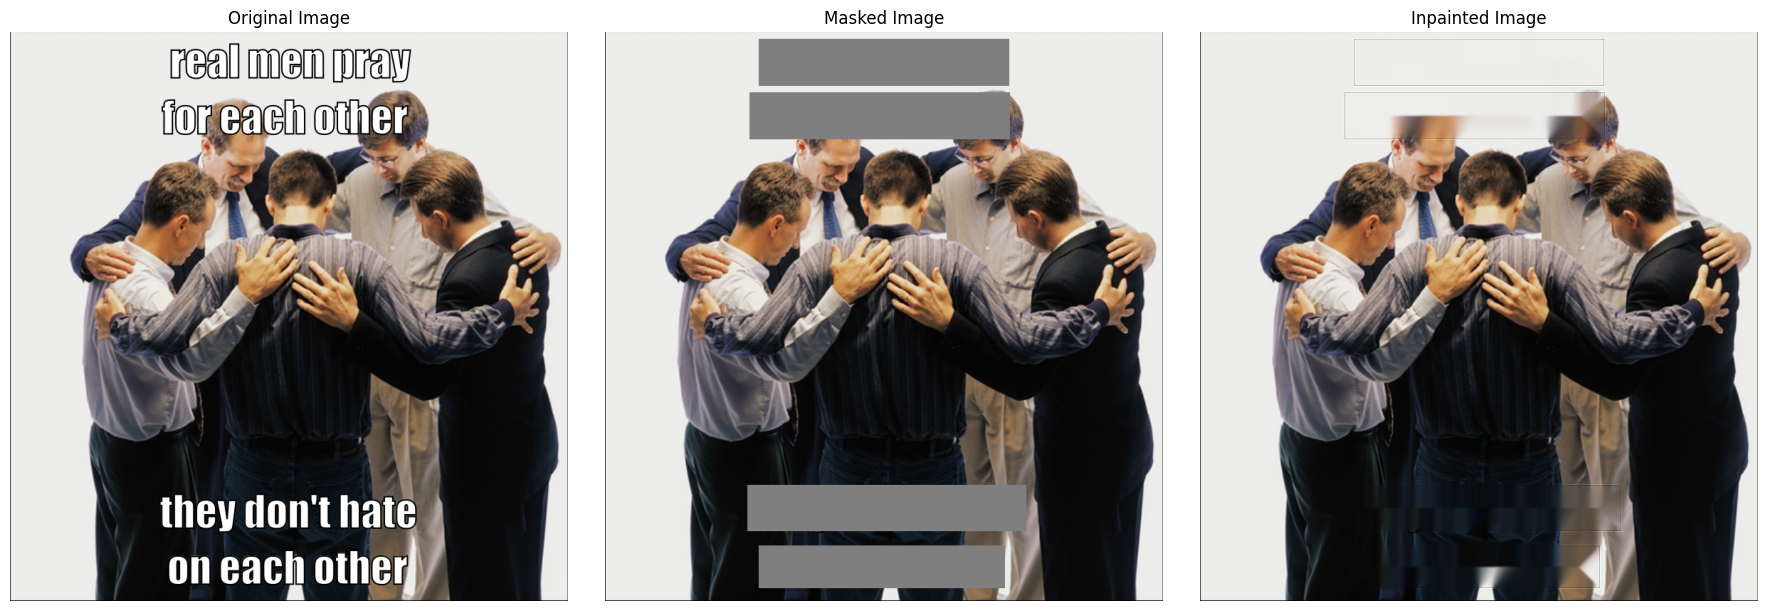


Visualizing results for: 46123.png


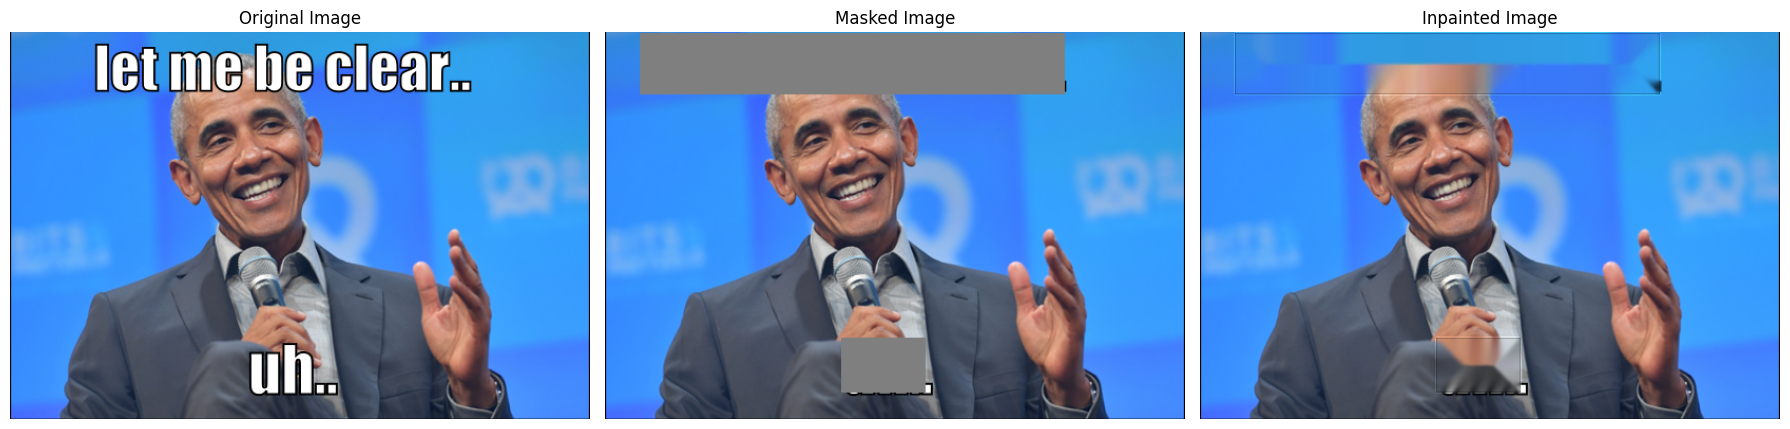

In [43]:
import matplotlib.pyplot as plt
def visualize_text_detection_results(original_img_path):
    masked, inpainted = transform_image(original_img_path)
    original = cv2.imread(original_img_path)
    

    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    masked_rgb = cv2.cvtColor(masked, cv2.COLOR_BGR2RGB)
    inpainted_rgb = cv2.cvtColor(inpainted, cv2.COLOR_BGR2RGB)
    

    plt.figure(figsize=(18, 6))
    
    plt.subplot(1, 3, 1)
    plt.imshow(original_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(masked_rgb)
    plt.title('Masked Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(inpainted_rgb)
    plt.title('Inpainted Image')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

import random
sample_images = random.sample(img_fns, 2)

for img_fn in sample_images:
    img_path = os.path.join(source_dir, img_fn)
    print(f"\nVisualizing results for: {img_fn}")
    visualize_text_detection_results(img_path)

In [ ]:
def transform_and_save_image(img_fn):
    img_fp = os.path.join(source_dir, img_fn)
    img_fp_masked = os.path.join(target_dir_masked, img_fn)
    img_fp_inpainted = os.path.join(target_dir_inpainted, img_fn)

    img_masked, img_inpainted = transform_image(img_fp)
    cv2.imwrite(img_fp_masked, img_masked)
    cv2.imwrite(img_fp_inpainted, img_inpainted)

with Pool(64) as pool:
    #pool.map(transform_and_save_image, img_fns)
    for _ in tqdm(pool.imap_unordered(transform_and_save_image, img_fns), total=len(img_fns)):
        pass

Exception in thread Thread-5:
Traceback (most recent call last):
  File "d:\ProgramData\Anaconda3\lib\threading.py", line 980, in _bootstrap_inner
    self.run()
  File "d:\ProgramData\Anaconda3\lib\threading.py", line 917, in run
    self._target(*self._args, **self._kwargs)
  File "d:\ProgramData\Anaconda3\lib\multiprocessing\pool.py", line 519, in _handle_workers
    cls._wait_for_updates(current_sentinels, change_notifier)
  File "d:\ProgramData\Anaconda3\lib\multiprocessing\pool.py", line 499, in _wait_for_updates
    wait(sentinels, timeout=timeout)
  File "d:\ProgramData\Anaconda3\lib\multiprocessing\connection.py", line 884, in wait
    ready_handles = _exhaustive_wait(waithandle_to_obj.keys(), timeout)
  File "d:\ProgramData\Anaconda3\lib\multiprocessing\connection.py", line 816, in _exhaustive_wait
    res = _winapi.WaitForMultipleObjects(L, False, timeout)
ValueError: need at most 63 handles, got a sequence of length 66


  0%|          | 0/10000 [00:00<?, ?it/s]